# Exercício Prático – Pré-processamento de Dados com Python
**Dataset: Hotel Booking Demand**

## 1. Objetivo

Aplicar técnicas de pré-processamento ao conjunto de dados **Hotel Booking Demand**, já utilizado na atividade de análise exploratória.

Nesta atividade, não será necessário realizar novamente a análise exploratória dos dados. O foco será **identificar e tratar problemas encontrados anteriormente, transformar atributos e verificar como essas operações modificam os dados.**

Utilize Python e Pandas para realizar todas as operações.

## 2. Preparação
Carregue o conjunto de dados:

In [271]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/hotel_bookings.csv')
atributes_before = df.shape

Como a estrutura e as principais características do dataset já foram analisadas na atividade anterior, utilize essa análise como referência para decidir quais atributos precisam de tratamento.

## 3. Tratamento de valores ausentes
Na análise exploratória anterior, você identificou atributos com valores ausentes.

## Tarefa
Escolha **dois atributos que apresentam valores ausentes** e defina uma estratégia de tratamento para cada um.

Para cada atributo:
1. identifique a quantidade de valores ausentes;
2. escolha uma estratégia de tratamento;
3. aplique o tratamento;
4. verifique se os valores ausentes foram tratados.

Você pode utilizar, conforme o caso:
- substituição pela média;
- substituição pela mediana;
- substituição pela moda;
- substituição por uma categoria;
- remoção de registros;
- outra estratégia devidamente justificada.

4
488


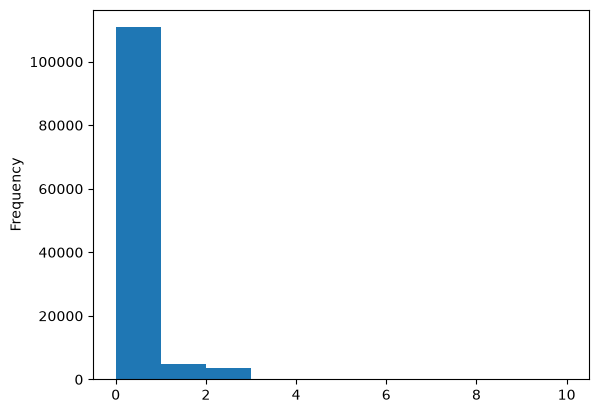

In [272]:
children_before = df["children"].isna().sum()
country_before = df["country"].isna().sum()
print(children_before)
print(country_before)

df['children'].plot.hist(
    bins=10,
    rwidth=1
)

plt.show()

In [273]:
df['children'] = df['children'].fillna(df['children'].median())
df['country'] = df['country'].fillna('Unknown')

print(df["children"].isna().sum())
print(df["country"].isna().sum())

0
0


## Questões
1. Quais dois atributos foram escolhidos e qual estratégia foi utilizada para tratar os valores ausentes de cada um?

**Resposta:** Os atributos escolhidos foram:
- `children`: Estrategia de substituição por mediana.
- `country`: Estrategia de substituição por categoria.
2. Quantos valores ausentes foram eliminados ou substituídos após o tratamento?

**Resposta:** Foram removidos dos atributos `children` e `country`, 4 e 488 valores respectivamente.

3. Por que a estratégia escolhida é adequada para cada atributo?

**Resposta:** Eu escolhi a estrategia de Substituição por mediana para  o atributo `children`, pelo motivo que a mediana é menos sensivel a valores extremos. E para o atributo `country` eu escolhi a estrategia de substituição por categoria, pelo fato do dele ser um atributo de valor categorico.

## 4. Remoção de registros duplicados
Verifique novamente a existência de registros duplicados:

In [274]:
allRecords = len(df)

Caso existam, remova-os utilizando:

In [275]:
df = df.drop_duplicates()
after = len(df)
removed = allRecords - after

print('Records before:', allRecords)
print('Duplicate records removed: ', removed)
print('Records after: ', after)

Records before: 119390
Duplicate records removed:  31994
Records after:  87396


4. Quantos registros foram removidos e quantas instâncias permanecem no conjunto após a remoção?

**Resposta:** Foram removidos **31994** registros e permanecem **87396** instancia de **119390**

## 5. Criação e transformação de atributos
Crie um novo atributo denominado  `total_nights`, representando o número total de noites da reserva:

In [276]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)
display(df['total_nights'])

0         0
1         0
2         1
3         1
4         2
         ..
119385    7
119386    7
119387    7
119388    7
119389    9
Name: total_nights, Length: 87396, dtype: int64

Em seguida, crie uma variável categórica `stay_length` para classificar as reservas em três grupos:

- **Curta:** até 2 noites;

- **Média:** 3 a 5 noites;

- **Longa:** mais de 5 noites.

Utilize `pd.cut()`.

In [277]:
df['stay_category'] = pd.cut(
    df['total_nights'],
    bins=[-1, 2 ,5, float("inf")],
    labels=['Curta', 'Media', 'Longa']
)
display(df['stay_category'])

## o sort.index() serve para retornar os valores em ordem
display(df['stay_category'].value_counts().sort_index())

0         Curta
1         Curta
2         Curta
3         Curta
4         Curta
          ...  
119385    Longa
119386    Longa
119387    Longa
119388    Longa
119389    Longa
Name: stay_category, Length: 87396, dtype: category
Categories (3, str): ['Curta' < 'Media' < 'Longa']

stay_category
Curta    33580
Media    38156
Longa    15660
Name: count, dtype: int64

## Questões
5. Quantas reservas pertencem a cada categoria de `stay_length`?

**Resposta:**
- **Curta:** 33580
- **Medio:** 38156
- **Longa:** 15660

6. Qual categoria representa a maior parte das reservas?

**Resposta:** A categoria de estadia **Medio**

7. Compare a distribuição de `adr` entre as três categorias de duração. Qual grupo apresenta o maior **ADR médio**?

**Resposta:** A categoria de estadia **Medio**

,stay_category,adr
0,Curta,99.122624
1,Media,110.949308
2,Longa,110.570271


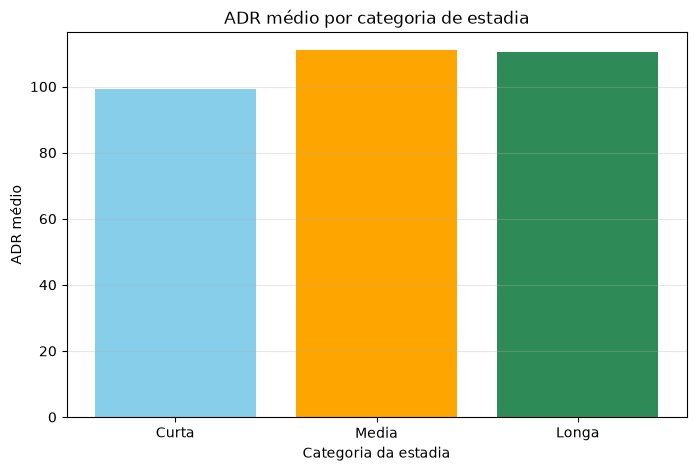

In [278]:
adr_medio = (
    df.groupby("stay_category", observed=False)["adr"]
      .mean()
      .reset_index()
)

display(adr_medio)

##Distribuided graph ADR
plt.figure(figsize=(8, 5))

plt.bar(
    adr_medio["stay_category"],
    adr_medio["adr"],
    color=["skyblue", "orange", "seagreen"]
)

plt.title("ADR médio por categoria de estadia")
plt.xlabel("Categoria da estadia")
plt.ylabel("ADR médio")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 6. Normalização
Utilize o atributo `adr` para criar uma nova variável denominada `adr_normalized`.

Normalize os valores para o intervalo **[0, 1]** utilizando a transformação Min-Max:


$$ x' = \frac{x - \min(x)}{\max(x) - \min(x)} $$

In [279]:
adr_medio["adr_normalized"] = (
    (adr_medio["adr"] - adr_medio["adr"].min()) /
    (adr_medio["adr"].max() - adr_medio["adr"].min())
)
display(adr_medio[["stay_category", "adr", "adr_normalized"]])

,stay_category,adr,adr_normalized
0,Curta,99.122624,0.000000
1,Media,110.949308,1.000000
2,Longa,110.570271,0.967951


## Questão
8. Após a normalização, qual é o menor e o maior valor de `adr_normalized`? Explique o que significa transformar o atributo `adr` para essa nova escala.

**Resposta:** O maior valor é 1(`Medio`) e o menor valor é 0(`Curta`), e transformar os valores limitando eles entre 0 e 1, não significa mudar o a ordem nem a relação entre eles, ajuda na hora da analise dos dados além de uma ocmparação e visualização mais facil entre os valores.

## 7. Comparação final
Ao final do exercício, apresente uma pequena tabela comparando o conjunto antes e depois do pré-processamento:

| **Característica** | **Antes** | **Depois** |
|---|---:|---:|
| Número de instâncias | 119390 | 87396 |
| Número de atributos | 32 | 34 |
| Valores ausentes nos atributos escolhidos | 4, 488 | 0, 0 |
| Registros duplicados | 31994 | 0 |

**Conclusão:**  
[Descreva aqui as principais mudanças observadas após o tratamento dos dados.]

**O que foi necessário modificar nos dados para que eles estivessem mais adequados para uma etapa posterior de Mineração de Dados?**

Records before: 119390
Duplicate records removed:  31994
Records after:  87396

In [ ]:
print('Atributes Numbers Before', atributes_before[1])
print('Atributes Numbers After', df.shape[1])
print('Instances Numbers before:', allRecords)
print('Instances Numbers Afiter:', df.shape[0])
print('Atributes Null in children Before and after', children_before, df['children'].isna().sum())
print('Atributes Null in country Before and after', country_before, df['country'].isna().sum())
print('Duplicate Records before:', removed)
print('Duplicade Records after: ', df.duplicated().sum())

Atributes Numbers Before 32
Atributes Numbers After 34
Instances Numbers before: 119390
Instances Numbers Afiter: 87396
Atributes Null in children Before and after 4 0
Atributes Null in country Before and after 488 0
Duplicate Records before: 31994
Duplicade Records after:  0


## Entrega
Entregue um **Jupyter Notebook (`.ipynb`)** contendo:
- código Python;
- resultados das operações;
- respostas às 8 questões;
- tabela comparativa final;
- justificativas das estratégias de pré-processamento.

O notebook deverá ser executado integralmente antes da entrega e não deverá conter células com erro.

## Conceitos avaliados
- tratamento de valores ausentes;
- remoção de duplicatas;
- criação de novos atributos;
- transformação de atributos;
- discretização;
- normalização;
- interpretação dos efeitos do pré-processamento.

**Observação:** não é necessário repetir a análise exploratória realizada na atividade anterior. O aluno deve utilizar os conhecimentos obtidos naquela atividade para tomar decisões de pré-processamento nesta etapa.